In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from worldcup.tournament import load_teams, get_groups, get_group_matches
from worldcup.simulator import GroupStageSimulator
from worldcup.algorithms.poisson import PoissonGoalModel, _poisson_pmf
from worldcup.algorithms.animaniacs import AnimaniacsRatingModel, _SONG_ORDER, _TEAM_ALIASES

sns.set_theme(style='whitegrid', palette='muted')

# ── Configure model here ──────────────────────────────────────────────────────
rating_model = AnimaniacsRatingModel()
predictor = PoissonGoalModel(rating_model, base_lambda=1.3, alpha=0.3, max_ratio=10.0)
N_SIMULATIONS = 20_000
SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

teams = load_teams()
groups = get_groups(teams)
flag_map  = {t.name: t.flag  for t in teams}
group_map = {t.name: t.group for t in teams}

rankings = pd.read_csv('../data/rankings.csv').set_index('country')

# Animaniacs model

## Algorithm

Animaniacs derives an "effective Elo" rating purely from where a team's country is
name-checked in the *Animaniacs* "Yakko's World" song (1993, lyrics in `lyrics.txt`).

**Hypothesis:** countries sung about earlier in "Yakko's World" are footballing
powerhouses — the song reels off ~196 places in roughly geographic order, starting
with the USA, Canada, Mexico, Panama...

### Rating formula

Each place in the song gets a rank $r$ (1 = sung first, 196 = sung last). The full
real-world range of FIFA Elo points is spread linearly across these ranks, centred on
the average FIFA Elo:

$$\text{elo\_per\_step} = \frac{\text{points}_{\max} - \text{points}_{\min}}{N_{\text{song}} - 1},
\qquad \text{mid\_rank} = \frac{1 + N_{\text{song}}}{2}$$

$$\text{rating}(r) = \overline{\text{points}} + \text{elo\_per\_step} \cdot (\text{mid\_rank} - r)$$

A team sung first (the USA, $r=1$) gets the highest rating; a team sung near the end
(Cape Verde, $r=193$) gets close to the lowest. Teams that didn't exist in 1993, or
whose name has since changed, are mapped onto a near-neighbour's slot via
`_TEAM_ALIASES` (e.g. Croatia → Yugoslavia, Czechia → Czechoslovakia, Curaçao →
Netherlands).

The rating feeds into the Poisson goal model:
$$\lambda_h = \lambda_0 \cdot \text{ratio}^{\alpha}, \qquad \lambda_a = \frac{\lambda_0}{\text{ratio}^{\alpha}}$$
with $\lambda_0 = 1.3$, $\alpha = 0.3$, max ratio cap = 10.

### Component breakdown — all WC teams

In [2]:
rows = []
for t in sorted(teams, key=lambda t: rating_model.rate(t), reverse=True):
    rank = rating_model._song_rank(t.name)
    place = _TEAM_ALIASES.get(t.name, t.name)
    actual_rank = int(rankings.loc[t.name, 'fifa_ranking'])
    actual_pts  = float(rankings.loc[t.name, 'fifa_points'])
    anim_elo = rating_model.rate(t)
    rows.append({
        'Team':             f'{flag_map[t.name]} {t.name}',
        'Song place':       place,
        'Song rank':        rank,
        'Animaniacs Elo':   round(anim_elo, 1),
        'Actual FIFA rank': actual_rank,
        'Actual FIFA pts':  round(actual_pts, 1),
        'Δ (Animaniacs − actual)': round(anim_elo - actual_pts, 1),
    })

breakdown = pd.DataFrame(rows)
breakdown.style \
    .hide(axis='index') \
    .background_gradient(subset='Animaniacs Elo',           cmap='RdYlGn',  vmin=600, vmax=1900) \
    .background_gradient(subset='Actual FIFA pts',           cmap='RdYlGn',  vmin=600, vmax=1900) \
    .background_gradient(subset='Song rank',                 cmap='RdYlGn_r', vmin=1, vmax=len(_SONG_ORDER)) \
    .background_gradient(subset='Δ (Animaniacs − actual)',   cmap='RdBu',    vmin=-600, vmax=600)

Team,Song place,Song rank,Animaniacs Elo,Actual FIFA rank,Actual FIFA pts,Δ (Animaniacs − actual)
🇺🇸 United States,United States,1,1807.400000,17,1671.200000,136.200000
🇨🇦 Canada,Canada,2,1801.500000,30,1559.500000,242.000000
🇲🇽 Mexico,Mexico,3,1795.600000,14,1687.500000,108.100000
🇵🇦 Panama,Panama,4,1789.700000,34,1539.200000,250.500000
🇭🇹 Haiti,Haiti,5,1783.700000,83,1293.100000,490.600000
🇨🇴 Colombia,Colombia,14,1730.400000,13,1698.300000,32.100000
🇦🇷 Argentina,Argentina,20,1694.900000,1,1876.100000,-181.200000
🇪🇨 Ecuador,Ecuador,21,1689.000000,23,1598.500000,90.500000
🇧🇷 Brazil,Brazil,23,1677.100000,6,1765.900000,-88.700000
🇵🇾 Paraguay,Paraguay,31,1629.800000,41,1505.300000,124.400000


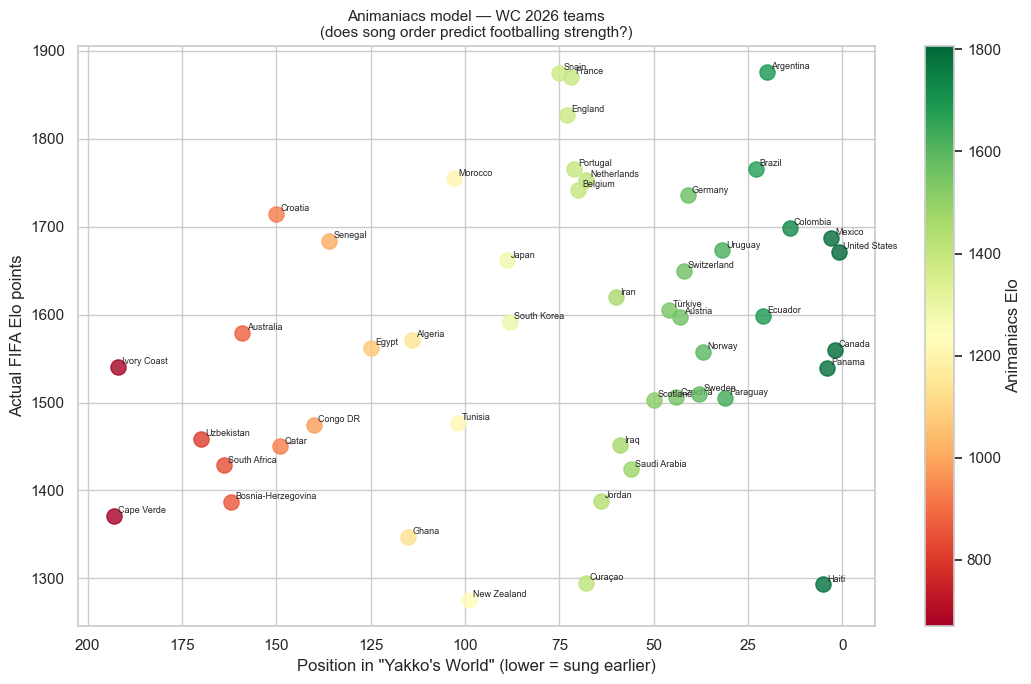

In [3]:
# Scatter: song rank vs actual FIFA points, colour = Animaniacs Elo
fig, ax = plt.subplots(figsize=(11, 7))

anim_elos = [rating_model.rate(t) for t in teams]
norm = plt.Normalize(min(anim_elos), max(anim_elos))
cmap = plt.cm.RdYlGn

for t in teams:
    rank = rating_model._song_rank(t.name)
    actual_pts = float(rankings.loc[t.name, 'fifa_points'])
    elo = rating_model.rate(t)
    ax.scatter(rank, actual_pts, s=120, alpha=0.8, color=cmap(norm(elo)), zorder=3)
    ax.annotate(t.name, (rank, actual_pts), fontsize=6.5,
                xytext=(3, 2), textcoords='offset points')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Animaniacs Elo')

ax.set_xlabel('Position in "Yakko\'s World" (lower = sung earlier)')
ax.set_ylabel('Actual FIFA Elo points')
ax.set_title('Animaniacs model — WC 2026 teams\n(does song order predict footballing strength?)', fontsize=11)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

### Example prediction — United States vs Cape Verde

United States: sung at #1 → Animaniacs Elo 1807.4
Cape Verde: sung at #193 → Animaniacs Elo 670.3
λ_home = 1.751,  λ_away = 0.965


Outcome,Probability
🇺🇸 United States win,55.8%
Draw,23.5%
🇨🇻 Cape Verde win,20.7%


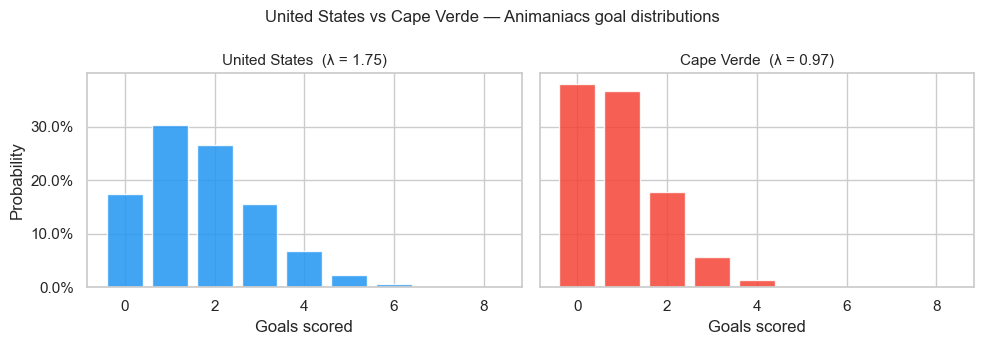

In [4]:
example_home = next(t for t in teams if t.name == 'United States')
example_away = next(t for t in teams if t.name == 'Cape Verde')

rank_h = rating_model._song_rank(example_home.name)
rank_a = rating_model._song_rank(example_away.name)
λ_h, λ_a = predictor.lambdas(example_home, example_away)
p_home, p_draw, p_away = predictor.predict(example_home, example_away)

print(f'{example_home.name}: sung at #{rank_h} → Animaniacs Elo {rating_model.rate(example_home):.1f}')
print(f'{example_away.name}: sung at #{rank_a} → Animaniacs Elo {rating_model.rate(example_away):.1f}')
print(f'λ_home = {λ_h:.3f},  λ_away = {λ_a:.3f}')

example_df = pd.DataFrame([
    {'Outcome': f'{example_home.flag} {example_home.name} win', 'Probability': p_home},
    {'Outcome': 'Draw',                                          'Probability': p_draw},
    {'Outcome': f'{example_away.flag} {example_away.name} win', 'Probability': p_away},
])
display(example_df.style.hide(axis='index')
        .format({'Probability': '{:.1%}'})
        .bar(subset='Probability', color='#90CAF9', vmin=0, vmax=1))

max_g = 8
goals = np.arange(0, max_g + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].bar(goals, [_poisson_pmf(g, λ_h) for g in goals], color='#2196F3', alpha=0.85)
axes[0].set_title(f'{example_home.name}  (λ = {λ_h:.2f})', fontsize=11)
axes[0].set_xlabel('Goals scored'); axes[0].set_ylabel('Probability')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[1].bar(goals, [_poisson_pmf(g, λ_a) for g in goals], color='#F44336', alpha=0.85)
axes[1].set_title(f'{example_away.name}  (λ = {λ_a:.2f})', fontsize=11)
axes[1].set_xlabel('Goals scored')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
fig.suptitle(f'{example_home.name} vs {example_away.name} — Animaniacs goal distributions', fontsize=12)
plt.tight_layout(); plt.show()

---

## Group stage qualification probabilities

In [5]:
sim = GroupStageSimulator(predictor, n=N_SIMULATIONS, seed=SEED)
results = sim.run(groups)
df = results.to_dataframe()

df['flag']      = df['team'].map(flag_map)
df['group']     = df['team'].map(group_map)
df['Team']      = df['flag'] + ' ' + df['team']
df['song_rank'] = df['team'].map(rating_model._song_rank)
df['anim_elo']  = df['team'].map(lambda n: round(rating_model.rate(next(t for t in teams if t.name == n)), 1))

qual_table = df[['group', 'Team', 'song_rank', 'anim_elo', 'p_qualify', 'p_group_winner', 'p_runner_up', 'p_best_third', 'p_eliminated']].copy()
qual_table.columns = ['Group', 'Team', 'Song rank', 'Animaniacs Elo', 'Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']

qual_table.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']}) \
    .background_gradient(subset='Qualify',        cmap='RdYlGn',   vmin=0, vmax=1) \
    .background_gradient(subset='Eliminated',     cmap='RdYlGn_r', vmin=0, vmax=1) \
    .background_gradient(subset='Song rank',      cmap='RdYlGn_r', vmin=1, vmax=len(_SONG_ORDER)) \
    .background_gradient(subset='Animaniacs Elo', cmap='RdYlGn',   vmin=600, vmax=1900)

Group,Team,Song rank,Animaniacs Elo,Qualify,1st,2nd,Best 3rd,Eliminated
B,🇨🇦 Canada,2,1801.500000,80.2%,36.9%,28.5%,14.9%,19.8%
K,🇨🇴 Colombia,14,1730.400000,79.8%,37.2%,27.5%,15.1%,20.2%
L,🇵🇦 Panama,4,1789.700000,78.7%,36.8%,27.0%,14.9%,21.3%
A,🇲🇽 Mexico,3,1795.600000,77.8%,34.9%,27.5%,15.3%,22.2%
E,🇪🇨 Ecuador,21,1689.000000,77.5%,33.3%,27.8%,16.4%,22.5%
H,🇺🇾 Uruguay,32,1623.800000,77.4%,33.1%,28.0%,16.4%,22.6%
B,🇨🇭 Switzerland,42,1564.600000,76.4%,31.9%,28.3%,16.2%,23.5%
D,🇺🇸 United States,1,1807.400000,76.1%,32.9%,27.7%,15.5%,23.9%
E,🇩🇪 Germany,41,1570.500000,75.2%,30.4%,28.0%,16.8%,24.8%
H,🇸🇦 Saudi Arabia,56,1481.700000,74.3%,29.2%,28.0%,17.1%,25.7%


---

## Match predictions

In [6]:
match_rows = []
for group_name, group_teams in sorted(groups.items()):
    for home, away in get_group_matches(group_teams):
        λ_h, λ_a = predictor.lambdas(home, away)
        p_hw, p_d, p_aw = predictor.predict(home, away)
        match_rows.append({
            'Group':      group_name,
            'Home':       f'{home.flag} {home.name}',
            'Away':       f'{away.flag} {away.name}',
            'λ home':     round(λ_h, 3),
            'λ away':     round(λ_a, 3),
            'Home win %': p_hw,
            'Draw %':     p_d,
            'Away win %': p_aw,
        })

matches_df = pd.DataFrame(match_rows)
matches_df.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Home win %', 'Draw %', 'Away win %']}) \
    .background_gradient(subset='Home win %', cmap='Blues',  vmin=0, vmax=1) \
    .background_gradient(subset='Away win %', cmap='Reds',   vmin=0, vmax=1) \
    .background_gradient(subset='Draw %',     cmap='Greens', vmin=0, vmax=1)

Group,Home,Away,λ home,λ away,Home win %,Draw %,Away win %
A,🇲🇽 Mexico,🇿🇦 South Africa,1.632000,1.036000,51.3%,24.7%,24.1%
A,🇲🇽 Mexico,🇰🇷 South Korea,1.435000,1.178000,43.0%,26.1%,31.0%
A,🇲🇽 Mexico,🇨🇿 Czechia,1.358000,1.245000,39.5%,26.3%,34.2%
A,🇿🇦 South Africa,🇰🇷 South Korea,1.143000,1.478000,29.3%,25.8%,44.9%
A,🇿🇦 South Africa,🇨🇿 Czechia,1.082000,1.562000,26.3%,25.3%,48.4%
A,🇰🇷 South Korea,🇨🇿 Czechia,1.230000,1.374000,33.5%,26.3%,40.2%
B,🇨🇦 Canada,🇧🇦 Bosnia-Herzegovina,1.626000,1.039000,51.1%,24.7%,24.2%
B,🇨🇦 Canada,🇶🇦 Qatar,1.585000,1.066000,49.4%,25.1%,25.6%
B,🇨🇦 Canada,🇨🇭 Switzerland,1.356000,1.246000,39.4%,26.3%,34.3%
B,🇧🇦 Bosnia-Herzegovina,🇶🇦 Qatar,1.267000,1.334000,35.2%,26.4%,38.4%
